### Summary of Deep Learning Models Performance

In [1]:
import os
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

DATA_DIR = "results"
INDEX_EVENTS = ["Borrow", "Repay", "Deposit", "Withdraw"]
OUTCOME_EVENTS = ["Borrow", "Repay", "Deposit", "Withdraw", "Account Liquidated"]

os.makedirs(DATA_DIR, exist_ok=True)

In [2]:
def load_all_results(data_dir=DATA_DIR):
    json_files = [f for f in os.listdir(data_dir) if f.endswith(".json")]
    all_data = {}

    for jf in json_files:
        path = os.path.join(data_dir, jf)
        print(path)
        with open(path, "r") as f:
            data = json.load(f)
        index_name = data.get("index", jf.replace("DEEPSURV_", "").replace(".json", ""))
        all_data[index_name.lower()] = data
    return all_data

results_data = load_all_results()

results/deephit_borrow.json
results/deephit_withdraw.json
results/deephit_repay.json
results/deephit_deposit.json


In [3]:
def extract_best_trials(results_dict):
    best_records = []

    for index, content in results_dict.items():
        for outcome, trials in content["trials"].items():
            if not trials:
                continue
            df = pd.DataFrame(trials)
            df["index_event"] = index.title()
            df["outcome_event"] = outcome.title()

            best_row = df.loc[df["c_index"].idxmax()]
            best_records.append(best_row)

    best_df = pd.DataFrame(best_records)
    return best_df

best_trials_df = extract_best_trials(results_data)
print(best_trials_df.head())

                     timestamp  model_arch  \
11  2025-10-13T01:19:45.285694  MLPVanilla   
24  2025-10-13T03:05:35.108608  MLPVanilla   
8   2025-10-13T01:49:00.177616  MLPVanilla   
2   2025-10-13T02:11:57.987328  MLPVanilla   
6   2025-10-13T10:14:05.645277  MLPVanilla   

                                               config   c_index  \
11  {'hidden_sizes': [64, 256, 256], 'dropout': 0....  0.690984   
24  {'hidden_sizes': [64, 64, 512, 256, 32, 16, 51...  0.733340   
8   {'hidden_sizes': [128, 64, 512, 512, 64, 256],...  0.699760   
2   {'hidden_sizes': [256, 64, 128, 256, 512, 128]...  0.676607   
6   {'hidden_sizes': [128, 128, 128, 16, 16, 32, 1...  0.891226   

   feature_selection  feature_count  seed  clip_grad  clip_value  durations  \
11              MRMR            105   123      False         NaN        150   
24              MRMR             95   123       True         1.0        250   
8               MRMR             10   123       True         1.0        150   
2   

In [4]:
pivot_df = best_trials_df.pivot_table(
    index="index_event", columns="outcome_event", values="c_index"
)
pivot_df = pivot_df.reindex(index=INDEX_EVENTS, columns=OUTCOME_EVENTS)
print(pivot_df)

outcome_event    Borrow     Repay   Deposit  Withdraw  Account Liquidated
index_event                                                              
Borrow              NaN  0.690984  0.699760  0.676607            0.733340
Repay          0.743911       NaN  0.739499  0.719039            0.683516
Deposit        0.787464  0.758310       NaN  0.748045            0.725915
Withdraw       0.891226  0.879518  0.817564       NaN            0.746390


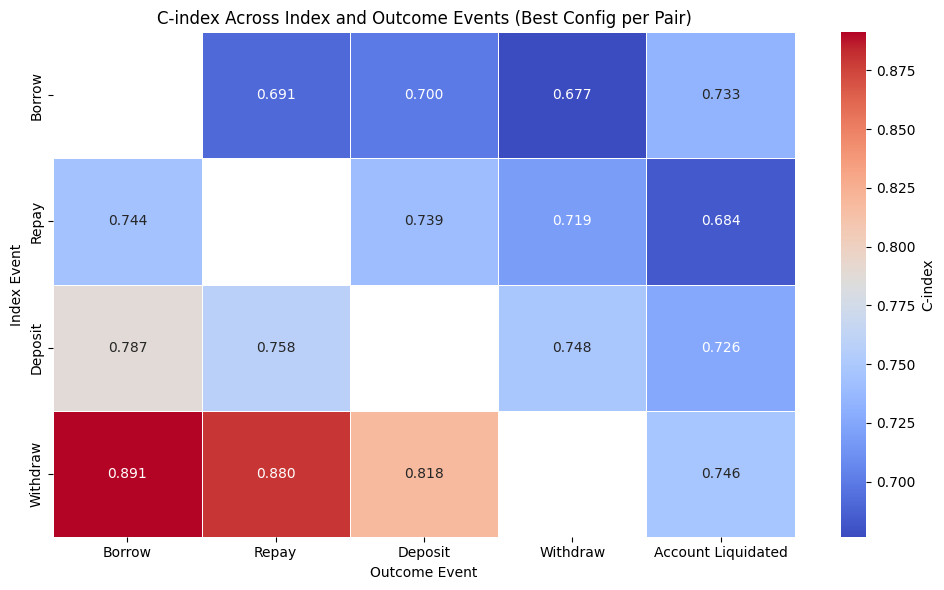

In [5]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_df,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"label": "C-index"},
)
plt.title("C-index Across Index and Outcome Events (Best Config per Pair)")
plt.ylabel("Index Event")
plt.xlabel("Outcome Event")
plt.tight_layout()
plt.show()

### Analysis Of Evaluation Techniques and Model Errors with Parameters

Evaluation Criteria: Risk Score

For linear Cox models, the hazard function is h(t | x)=h_0(t)e^n where n is a linear predictor ie. weights*biases summed.
The risk score is just the linear component from the hazard model and we taking the log of the exponential portion and taking out the baseline hazard function.
The risk score DeepSurv is this same component as in the linear Cox model, but it is replaced by a non-linear component derived from the outputs of the neural network.

While the baseline hazard function takes time as a dependency, the risk score alone can be used for relative risk among individuals which is enough for calculating the concordance index.

In [6]:
# Analyzing all failing trials where the model could not properly predict the outcomes
# Extract all trials where c_index = -1 (indicating failed runs)
failing_trials = []

for index, content in results_data.items():
    for outcome, trials in content["trials"].items():
        for t in trials:
            if t["c_index"] == -1:
                t["index_event"] = index.title()
                t["outcome_event"] = outcome.title()
                failing_trials.append(t)

failing_df = pd.DataFrame(failing_trials)
print(f"\nTotal failing trials: {len(failing_df)}")
print(failing_df.head(3))


Total failing trials: 0
Empty DataFrame
Columns: []
Index: []


In [7]:
# Convert nested config dicts into separate columns
config_df = pd.json_normalize(failing_df["config"])
fail_summary_df = pd.concat([failing_df[["index_event", "outcome_event"]], config_df], axis=1)

# 1️⃣ Mean number of hidden layers
fail_summary_df["num_layers"] = fail_summary_df["hidden_sizes"].apply(len)
mean_layers = fail_summary_df["num_layers"].mean()
median_layers = fail_summary_df["num_layers"].median()

# 2️⃣ Three most common activation functions
top_activations = fail_summary_df["activation"].value_counts().head(3)

# 3️⃣ Average learning rate
mean_lr = fail_summary_df["learning_rate"].mean()

# 4️⃣ Top 2 most common learning rates
top_lr = fail_summary_df["learning_rate"].value_counts().head(2)

# 5️⃣ Optimizer usage counts
optimizer_counts = fail_summary_df["optimizer"].value_counts()

# Clean display
print("="*60)
print("⚠️ GLOBAL FAILING MODEL ANALYSIS ⚠️")
print("="*60)
print(f"Mean # Hidden Layers: {mean_layers:.2f}")
print(f"Median # Hidden Layers: {median_layers:.2f}")
print("\nTop 3 Activations:")
for i, (a, c) in enumerate(top_activations.items(), 1):
    print(f"  {i}. {a}  ({c} uses)")
print(f"\nAverage Learning Rate: {mean_lr:.6f}")
print("\nTop 2 Learning Rates:")
for i, (lr, c) in enumerate(top_lr.items(), 1):
    print(f"  {i}. {lr}  ({c} uses)")
print("\nOptimizer Counts:")
for opt, count in optimizer_counts.items():
    print(f"  {opt}: {count}")
print("="*60)


KeyError: 'config'

In [ ]:
# Count failing trials per Index→Outcome pair
failure_counts = (
    failing_df.groupby(["index_event", "outcome_event"])
    .size()
    .reset_index(name="fail_count")
)
# Optional DataFrame display (for plotting)
failure_counts_sorted = failure_counts.sort_values("fail_count", ascending=False)
display(failure_counts_sorted)

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=failure_counts_sorted,
    x="outcome_event",
    y="fail_count",
    hue="index_event",
    palette="tab10"
)
plt.title("Number of Failing Trials per Index→Outcome Pair (C-index = -1)")
plt.ylabel("Fail Count")
plt.xlabel("Outcome Event")
plt.legend(title="Index Event")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Issues That Came Up When Running Models

* In some index to outcome events like Withdraw to Account Liquidated, the models converged, but when predicting the risk scores, the risk scores were all Nans values. This can happen for 2 main reasons: numerical instability or improper hazard function evaluation.
* Numerical stability mainly happens if gradients explode during training which can make some weights NaN.
* When trying to optimize the model, the model tries to maximize the log-likelihood but when uncensored events are very rare, the uncensored events can have extremely large gradients while the censored events can have extremely small gradients (near zero) which means that training becomes unstable.
* To avoid datasets where the uncensored data is an extremely small portion (such as in Withdraw to Account Liquidated where uncensored data made up only 0.9% of all samples), I downsampled the censored rows.
* Interestingly enough, some index to outcome event pairs like Withdraw to Repay had a very nice portion of uncensored data (20%), but it still failed to produce risk a large portion of the time (failed 35 times out of 50 trials!) so there may possibly be some issues with the distribution of the data that may be causing underlying issues.

### Future Analysis Steps
* Analyze how the gradients behave in the log-likehood function
* Analyze distribution of the index-outcome events that failed to understand if distribution concerns are causing numerical instability
* Analyze preprocessing steps that can be used to mitigate these failures
* Analyze architectures that we should smartly avoid
* Run DeepHit and N-MTLR on all index-outcome events (most of the code is already done for this). I need to review the preprocessing again to make it as clean as possible and update the file to make more components modular for any future runs.